In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import scipy
import os
import random

In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent   # adjust if needed
sys.path.append(str(project_root))

from combined_model.mydataset_tmp import Nutrition_RGBD

In [26]:
# TRAIN_TXT = "../splits/lunch_by_subject_combined_kcal_train.txt"
# TEST_TXT  = "../splits/lunch_by_subject_combined_kcal_test.txt"
TRAIN_TXT = "../splits/lunch_sub_train_test_val/train.txt"  # lunch_dinner/train_test_val_30_120
VAL_TXT = "../splits/lunch_sub_train_test_val/val.txt"
TEST_TXT = "../splits/lunch_sub_train_test_val/test.txt"

In [27]:
def save_checkpoint(path, model, optimizer=None, scheduler=None, epoch=None, best_score=None, extra=None):
    ckpt = {
        "model_state_dict": model.state_dict(),
        "epoch": epoch,
        "best_score": best_score,
    }
    if optimizer is not None:
        ckpt["optimizer_state_dict"] = optimizer.state_dict()
    if scheduler is not None:
        ckpt["scheduler_state_dict"] = scheduler.state_dict()
    if extra:
        ckpt.update(extra)
    torch.save(ckpt, path)

In [50]:

class CGMHead(nn.Module):
    def __init__(self, in_dim: int, hidden: int = 64, out_dim: int = 2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, x):
        return self.net(x)

In [51]:
class CGMHeadAttentionMicroFiLM(nn.Module):
    def __init__(
        self,
        in_dim,
        embed_dim=8,
        n_heads=1,
        out_dim=2,
        n_macros=5,
        n_micro=0,
        dropout=0.2,
        hidden=64,
        micro_hidden=32,
    ):
        super().__init__()

        self.n_macros = n_macros
        self.n_micro = n_micro

        n_clinical = in_dim - n_macros - n_micro
        self.n_clinical = n_clinical

        # Attention only over clinical + macro features
        self.n_attn_features = n_clinical + n_macros
        self.embed_dim = embed_dim

        self.feature_weights = nn.Parameter(
            torch.randn(self.n_attn_features, embed_dim) * 0.02
        )
        self.feature_biases = nn.Parameter(
            torch.zeros(self.n_attn_features, embed_dim)
        )

        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True,
        )

        self.attn_norm = nn.LayerNorm(embed_dim)

        # Microbiome branch only creates modulation parameters
        if n_micro > 0:
            self.micro_film = nn.Sequential(
                nn.Linear(n_micro, micro_hidden),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout),
                nn.Linear(micro_hidden, 2 * embed_dim),
            )
        else:
            self.micro_film = None

        # Same head size whether microbiome exists or not
        self.head = nn.Sequential(
            nn.Linear(self.n_attn_features * embed_dim, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, x):
        # Expected input order:
        # [macro features, clinical features, microbiome features]

        x_attn = x[:, :self.n_attn_features]

        tokens = (
            x_attn.unsqueeze(-1) * self.feature_weights.unsqueeze(0)
            + self.feature_biases.unsqueeze(0)
        )

        attn_out, _ = self.attn(tokens, tokens, tokens)
        tokens = self.attn_norm(tokens + attn_out)

        # Fuse microbiome immediately after attention
        if self.n_micro > 0:
            x_micro = x[:, self.n_attn_features:]

            gamma_beta = self.micro_film(x_micro)
            gamma, beta = gamma_beta.chunk(2, dim=-1)

            tokens = tokens * (1.0 + gamma.unsqueeze(1)) + beta.unsqueeze(1)

        out = tokens.flatten(1)
        return self.head(out)

In [456]:
def weighted_cgm_loss(pred, target, auc_weight=0.9):
    loss_iauc = nn.functional.smooth_l1_loss(pred[:, 0], target[:, 0], beta=1.0)
    loss_auc  = nn.functional.smooth_l1_loss(pred[:, 1], target[:, 1], beta=1.0)
    return loss_iauc + auc_weight * loss_auc, loss_iauc  # return both
    # return 0.5*loss_auc + 0.5*loss_iauc, loss_iauc

In [457]:
TARGET_COLS = ["iAUC_log", "AUC_log"]
feature_cols = ['Baseline_Libre', 'Age', 'BMI', 'A1c', 'HOMA', 'Insulin', 'TG', 'Cholesterol',
                            'HDL', 'Non_HDL', 'CHO_HDL_ratio', 'Fasting_BG', 'LDL', 'VLDL',
                            'total_calories', 'total_carb', 'total_protein', 'total_fat', #'Fiber',
                            'Gender', #'minutes_before', 'minutes_missing'
                ]

feature_cols_micro =['Lachnospiraceae', 'Streptococcaceae',
       'Bacteroidaceae', 'Enterobacteriaceae', 'Prevotellaceae'
    ]

In [458]:
trainset = Nutrition_RGBD('../cgmacros', TRAIN_TXT, TRAIN_TXT, glucose=True, microbiome=False, transform=None, norm_cols=feature_cols)

valset = Nutrition_RGBD('../cgmacros', VAL_TXT, VAL_TXT, glucose=True, microbiome=False, transform=None,
                         train=False, stats=trainset.stats, norm_cols=feature_cols)

testset = Nutrition_RGBD('../cgmacros', TEST_TXT, TEST_TXT, glucose=True, microbiome=False, transform=None,
                         train=False, stats=trainset.stats, norm_cols=feature_cols)

In [442]:
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)

In [443]:
BATCH_SIZE = 64

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, generator=g, num_workers=0,
                              pin_memory=True)
val_loader  = DataLoader(valset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(testset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [444]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'Device: {device}')
model = CGMHead(in_dim=len(feature_cols), hidden=128, out_dim=2) #out_dim=len(TARGET_COLS)).to(device)
# model = CGMHeadAttentionMicroFiLM(in_dim=len(feature_cols), hidden=128, out_dim=2).to(device)

# criterion = nn.MSELoss()
criterion = weighted_cgm_loss # nn.SmoothL1Loss(beta=1.0)
opt = torch.optim.Adam(model.parameters(), lr=5e-5, weight_decay=5e-4)
# scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.99)  # as RGBD
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode="min", factor=0.5, patience=15, min_lr=1e-6
)

Device: cpu


In [445]:
EPOCHS = 300
train_losses = []
test_losses = []
best_loss = np.inf
best_path = "CHECKPOINTS/cgmhead_best_rgbd_load.pt"

for epoch in range(EPOCHS):
    model.train()
    tr_loss = 0.0
    for x in train_loader:
        total_calories = x[2].to(device).float()
        total_fat = x[4].to(device).float()
        total_carb = x[5].to(device).float()
        total_protein = x[6].to(device).float()

        fiber = x[8].to(device).float()

        true_macros = torch.stack([total_calories, total_fat, total_carb, total_protein], dim=-1)
        tab_feats = torch.stack([t.to(device, dtype=torch.float32) for t in x[9:-3]], dim=1) #8 - Fiber

        yb = torch.stack([x[-2].to(device), x[-1].to(device)], dim=1)
        # yb = x[-2].to(device)
        # yb = yb[:, np.newaxis]

        xb = torch.cat([true_macros, tab_feats], dim=-1)
        # xb = torch.cat([tab_feats], dim=-1)

        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss, loss_iauc = criterion(pred, yb)

        opt.zero_grad()
        loss.backward()
        opt.step()

        tr_loss += loss.item() * xb.size(0)
    tr_loss /= len(trainset)

    model.eval()
    te_loss = 0.0
    # te_loss_iauc = 0.0
    with torch.no_grad():
        for x in val_loader:
            total_calories = x[2].to(device).float()
            total_fat = x[4].to(device).float()
            total_carb = x[5].to(device).float()
            total_protein = x[6].to(device).float()

            fiber = x[8].to(device).float()

            true_macros = torch.stack([total_calories, total_fat, total_carb, total_protein], dim=-1)
            tab_feats = torch.stack([t.to(device, dtype=torch.float32) for t in x[9:-3]], dim=1) #8 - Fiber

            yb = torch.stack([x[-2].to(device), x[-1].to(device)], dim=1)
            # yb = x[-2].to(device)
            # yb = yb[:, np.newaxis]

            xb = torch.cat([true_macros, tab_feats], dim=-1)
            # xb = torch.cat([tab_feats], dim=-1)

            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss, loss_iauc = criterion(pred, yb)
            te_loss += loss.item() * xb.size(0)

            # te_loss_iauc += loss_iauc.item() * xb.size(0)
    te_loss /= len(testset)

    train_losses.append(tr_loss)
    test_losses.append(te_loss)

    # te_loss_iauc /= len(testset)

    # scheduler.step(te_loss_iauc)
    # if te_loss_iauc + 1e-4 < best_loss:

    scheduler.step(te_loss)

    if te_loss + 1e-4 < best_loss:
        best_loss = te_loss
        # best_loss = te_loss_iauc
        save_checkpoint(
            best_path,
            model=model,
            optimizer=opt,
            scheduler=scheduler,
            epoch=epoch,
            best_score=best_loss,
        )
        print(f"Saved new best at epoch {epoch}: best loss = {best_loss:.6f}")

    if epoch % 5 == 0:
        print(f"Epoch {epoch:03d} | train loss={tr_loss:.6f} | val loss={te_loss:.6f}")

Saved new best at epoch 0: best loss = 0.840175
Epoch 000 | train loss=0.765874 | val loss=0.840175
Saved new best at epoch 1: best loss = 0.834580
Saved new best at epoch 2: best loss = 0.829065
Saved new best at epoch 3: best loss = 0.823649
Saved new best at epoch 4: best loss = 0.818276
Saved new best at epoch 5: best loss = 0.813161
Epoch 005 | train loss=0.734533 | val loss=0.813161
Saved new best at epoch 6: best loss = 0.808144
Saved new best at epoch 7: best loss = 0.803191
Saved new best at epoch 8: best loss = 0.798284
Saved new best at epoch 9: best loss = 0.793564
Saved new best at epoch 10: best loss = 0.788924
Epoch 010 | train loss=0.707584 | val loss=0.788924
Saved new best at epoch 11: best loss = 0.784398
Saved new best at epoch 12: best loss = 0.779831
Saved new best at epoch 13: best loss = 0.775303
Saved new best at epoch 14: best loss = 0.770878
Saved new best at epoch 15: best loss = 0.766447
Epoch 015 | train loss=0.683632 | val loss=0.766447
Saved new best at 

In [446]:
ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)
model.eval()
print("Loaded best model from epoch:", ckpt.get("epoch"), "best_score:", ckpt.get("best_score"))

Loaded best model from epoch: 130 best_score: 0.4298182826931194


In [447]:
pred_list_iauc = []
gt_list_iauc = []
pred_list_auc = []
gt_list_auc = []

y_std, y_mean = trainset.stats["std"]["iAUC_log"], trainset.stats["mean"]["iAUC_log"]

with torch.no_grad():
    for x in test_loader:
        total_calories = x[2].to(device).float()
        total_fat = x[4].to(device).float()
        total_carb = x[5].to(device).float()
        total_protein = x[6].to(device).float()

        fiber = x[8].to(device).float()

        # true_macros = torch.stack([total_calories, total_fat, total_carb, total_protein, fiber], dim=-1)
        true_macros = torch.stack([total_calories, total_fat, total_carb, total_protein], dim=-1)
        tab_feats = torch.stack([t.to(device, dtype=torch.float32) for t in x[9:-3]], dim=1)  #8 - Fiber

        yb = torch.stack([x[-2].to(device), x[-1].to(device)], dim=1)
        xb = torch.cat([true_macros, tab_feats], dim=-1)
        # xb = torch.cat([tab_feats], dim=-1)

        xb, yb = xb.to(device), yb.to(device) * y_std + y_mean
        pred = model(xb) * y_std + y_mean

        pred_list_iauc.append(np.exp(pred[:,0].cpu()))
        gt_list_iauc.append(np.exp(yb[:,0].cpu()))
        pred_list_auc.append(np.exp(pred[:,1].cpu()))
        gt_list_auc.append(np.exp(yb[:,1].cpu()))


pred_array, gt_array = np.concatenate(pred_list_iauc, axis=0), np.concatenate(gt_list_iauc, axis=0)
print("iAUC:")
scipy.stats.pearsonr(pred_array, gt_array)

iAUC:


PearsonRResult(statistic=0.5844115818744485, pvalue=1.1757329141913776e-06)

In [448]:
pred_array, gt_array = np.concatenate(pred_list_auc, axis=0), np.concatenate(gt_list_auc, axis=0)
print("AUC:")
scipy.stats.pearsonr(pred_array, gt_array)

AUC:


PearsonRResult(statistic=0.7168408746964404, pvalue=1.7085940829249594e-10)

In [371]:
#+ MICROBIOME

In [459]:
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)

In [460]:
trainset = Nutrition_RGBD('../cgmacros', TRAIN_TXT, TRAIN_TXT, glucose=True, microbiome=True, transform=None,
                          norm_cols=feature_cols + feature_cols_micro)

valset = Nutrition_RGBD('../cgmacros', VAL_TXT, VAL_TXT, glucose=True, microbiome=True, transform=None,
                         train=False, stats=trainset.stats, norm_cols=feature_cols + feature_cols_micro)

testset = Nutrition_RGBD('../cgmacros', TEST_TXT, TEST_TXT, glucose=True, microbiome=True, transform=None,
                         train=False, stats=trainset.stats, norm_cols=feature_cols + feature_cols_micro)

BATCH_SIZE = 64

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, generator=g, num_workers=0,
                              pin_memory=True)
val_loader  = DataLoader(valset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(testset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [461]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'Device: {device}')
# model = CGMHead(in_dim=len(feature_cols + feature_cols_micro), hidden=128, out_dim=2).to(device)
model = CGMHeadAttentionMicroFiLM(in_dim=len(feature_cols + feature_cols_micro), hidden=128, n_micro=5, micro_hidden=16, out_dim=2).to(device)

# criterion = nn.MSELoss()
criterion = weighted_cgm_loss #nn.SmoothL1Loss(beta=1.0)
opt = torch.optim.Adam(model.parameters(), lr=5e-5, weight_decay=5e-4)
# scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.99)  # as RGBD
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode="min", factor=0.5, patience=15, min_lr=1e-6
)

Device: cpu


In [462]:
EPOCHS = 300
train_losses = []
test_losses = []
best_loss = np.inf
best_path = "CHECKPOINTS/cgmhead_best_rgbd_micro_load.pt"

for epoch in range(EPOCHS):
    model.train()
    tr_loss = 0.0
    for x in train_loader:
        total_calories = x[2].to(device).float()
        total_fat = x[4].to(device).float()
        total_carb = x[5].to(device).float()
        total_protein = x[6].to(device).float()

        fiber = x[8].to(device).float()

        # true_macros = torch.stack([total_calories, total_fat, total_carb, total_protein, fiber], dim=-1)
        # tab_feats = torch.stack([t.to(device, dtype=torch.float32) for t in x[9:-3]], dim=1) #8 - Fiber
        true_macros = torch.stack([total_calories, total_fat, total_carb, total_protein], dim=-1)
        tab_feats = torch.stack([t.to(device, dtype=torch.float32) for t in x[9:-3]], dim=1)  #8 - Fiber

        yb = torch.stack([x[-2].to(device), x[-1].to(device)], dim=1)
        # yb = x[-2].to(device)
        # yb = yb[:, np.newaxis]

        xb = torch.cat([true_macros, tab_feats], dim=-1)
        # xb = torch.cat([tab_feats], dim=-1)

        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss, loss_iauc = criterion(pred, yb)

        opt.zero_grad()
        loss.backward()
        opt.step()

        tr_loss += loss.item() * xb.size(0)
    tr_loss /= len(trainset)

    model.eval()
    te_loss = 0.0
    # te_loss_iauc = 0.0
    with torch.no_grad():
        for x in val_loader:
            total_calories = x[2].to(device).float()
            total_fat = x[4].to(device).float()
            total_carb = x[5].to(device).float()
            total_protein = x[6].to(device).float()

            fiber = x[8].to(device).float()

            # true_macros = torch.stack([total_calories, total_fat, total_carb, total_protein, fiber], dim=-1)
            # tab_feats = torch.stack([t.to(device, dtype=torch.float32) for t in x[9:-3]], dim=1) #8 - Fiber
            true_macros = torch.stack([total_calories, total_fat, total_carb, total_protein], dim=-1)
            tab_feats = torch.stack([t.to(device, dtype=torch.float32) for t in x[9:-3]], dim=1)  #8 - Fiber

            yb = torch.stack([x[-2].to(device), x[-1].to(device)], dim=1)
            # yb = x[-2].to(device)
            # yb = yb[:, np.newaxis]

            xb = torch.cat([true_macros, tab_feats], dim=-1)
            # xb = torch.cat([tab_feats], dim=-1)

            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss, loss_iauc = criterion(pred, yb)
            te_loss += loss.item() * xb.size(0)

            # te_loss_iauc += loss_iauc.item() * xb.size(0)
    te_loss /= len(testset)

    train_losses.append(tr_loss)
    test_losses.append(te_loss)

    # te_loss_iauc /= len(testset)

    # scheduler.step(te_loss_iauc)
    # if te_loss_iauc + 1e-4 < best_loss:

    scheduler.step(te_loss)

    if te_loss + 1e-4 < best_loss:
        best_loss = te_loss
        # best_loss = te_loss_iauc
        save_checkpoint(
            best_path,
            model=model,
            optimizer=opt,
            scheduler=scheduler,
            epoch=epoch,
            best_score=best_loss,
        )
        print(f"Saved new best at epoch {epoch}: best loss = {best_loss:.6f}")

    if epoch % 5 == 0:
        print(f"Epoch {epoch:03d} | train loss={tr_loss:.6f} | val loss={te_loss:.6f}")

Saved new best at epoch 0: best loss = 0.437106
Epoch 000 | train loss=0.385124 | val loss=0.437106
Saved new best at epoch 1: best loss = 0.429936
Saved new best at epoch 2: best loss = 0.423606
Saved new best at epoch 3: best loss = 0.418118
Saved new best at epoch 4: best loss = 0.413156
Saved new best at epoch 5: best loss = 0.408873
Epoch 005 | train loss=0.358650 | val loss=0.408873
Saved new best at epoch 6: best loss = 0.404985
Saved new best at epoch 7: best loss = 0.401602
Saved new best at epoch 8: best loss = 0.398480
Saved new best at epoch 9: best loss = 0.395774
Saved new best at epoch 10: best loss = 0.393279
Epoch 010 | train loss=0.337830 | val loss=0.393279
Saved new best at epoch 11: best loss = 0.391056
Saved new best at epoch 12: best loss = 0.388804
Saved new best at epoch 13: best loss = 0.386606
Saved new best at epoch 14: best loss = 0.384703
Saved new best at epoch 15: best loss = 0.382809
Epoch 015 | train loss=0.317106 | val loss=0.382809
Saved new best at 

In [463]:
ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)
model.eval()
print("Loaded best model from epoch:", ckpt.get("epoch"), "best_score:", ckpt.get("best_score"))

Loaded best model from epoch: 97 best_score: 0.3111108521283683


In [464]:
pred_list_iauc = []
gt_list_iauc = []
pred_list_auc = []
gt_list_auc = []

y_std, y_mean = trainset.stats["std"]["iAUC_log"], trainset.stats["mean"]["iAUC_log"]

with torch.no_grad():
    for x in test_loader:
        total_calories = x[2].to(device).float()
        total_fat = x[4].to(device).float()
        total_carb = x[5].to(device).float()
        total_protein = x[6].to(device).float()

        fiber = x[8].to(device).float()

        # true_macros = torch.stack([total_calories, total_fat, total_carb, total_protein, fiber], dim=-1)
        # tab_feats = torch.stack([t.to(device, dtype=torch.float32) for t in x[9:-3]], dim=1) #8 - Fiber
        true_macros = torch.stack([total_calories, total_fat, total_carb, total_protein], dim=-1)
        tab_feats = torch.stack([t.to(device, dtype=torch.float32) for t in x[9:-3]], dim=1)  #8 - Fiber

        yb = torch.stack([x[-2].to(device), x[-1].to(device)], dim=1)
        xb = torch.cat([true_macros, tab_feats], dim=-1)
        # xb = torch.cat([tab_feats], dim=-1)

        xb, yb = xb.to(device), yb.to(device) * y_std + y_mean
        pred = model(xb) * y_std + y_mean

        pred_list_iauc.append(np.exp(pred[:,0].cpu()))
        gt_list_iauc.append(np.exp(yb[:,0].cpu()))
        pred_list_auc.append(np.exp(pred[:,1].cpu()))
        gt_list_auc.append(np.exp(yb[:,1].cpu()))


pred_array, gt_array = np.concatenate(pred_list_iauc, axis=0), np.concatenate(gt_list_iauc, axis=0)
print("iAUC:")
scipy.stats.pearsonr(pred_array, gt_array)

iAUC:


PearsonRResult(statistic=0.7864736538239643, pvalue=1.5604629021462929e-13)

In [465]:
pred_array, gt_array = np.concatenate(pred_list_auc, axis=0), np.concatenate(gt_list_auc, axis=0)
print("AUC:")
scipy.stats.pearsonr(pred_array, gt_array)

AUC:


PearsonRResult(statistic=0.6887665991545889, pvalue=1.6402160758534561e-09)

In [64]:
class Wrapped2In(torch.nn.Module):
    def __init__(self, model, out_idx=0):
        super().__init__()
        self.model = model
        self.out_idx = out_idx

    def forward(self, x):
        y = self.model(x)
        if y.ndim == 2 and y.shape[1] > 1:
            y = y[:, self.out_idx:self.out_idx+1]
        return y

In [68]:
def collect_inputs(loader, device):
    all_tab_feats = []
    all_img_rgb = []
    all_img_rgbd = []

    for x in loader:
        # Adjust these indices if your dataset returns them differently
        # img_rgb = x[0].to(device, dtype=torch.float32)     # RGB image
        # img_rgbd = x[1].to(device, dtype=torch.float32)    # RGBD image

        total_calories = x[2].to(device, dtype=torch.float32)
        total_fat = x[4].to(device, dtype=torch.float32)
        total_carb = x[5].to(device, dtype=torch.float32)
        total_protein = x[6].to(device, dtype=torch.float32)

        true_macros = torch.stack(
            [total_calories, total_fat, total_carb, total_protein], dim=-1
        )

        tab_feats = torch.stack(
            [t.to(device, dtype=torch.float32) for t in x[8:-3]], dim=1
        )

        # same as in your training code
        xb = torch.cat([true_macros, tab_feats], dim=-1)

        all_tab_feats.append(xb)
        # all_img_rgb.append(img_rgb)
        # all_img_rgbd.append(img_rgbd)

    all_tab_feats = torch.cat(all_tab_feats, dim=0)
    # all_img_rgb = torch.cat(all_img_rgb, dim=0)
    # all_img_rgbd = torch.cat(all_img_rgbd, dim=0)

    return all_tab_feats#, all_img_rgb, all_img_rgbd


# collect train + test inputs
tab_train = collect_inputs(train_loader, device)
tab_val = collect_inputs(val_loader, device)
tab_test = collect_inputs(test_loader, device)

tab_all = torch.cat([tab_train, tab_val, tab_test], dim=0)
# rgb_all = torch.cat([rgb_train, rgb_test], dim=0)
# rgbd_all = torch.cat([rgbd_train, rgbd_test], dim=0)


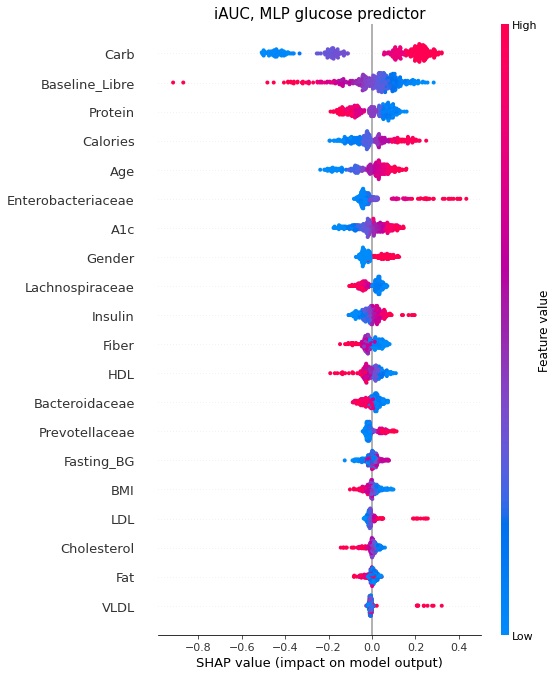

In [69]:
import shap

feature_cols_micro =['Lachnospiraceae', 'Streptococcaceae',
       'Bacteroidaceae', 'Enterobacteriaceae', 'Prevotellaceae'
    ]

feature_names = ['Calories', 'Fat', 'Carb', 'Protein', 'Fiber', 'Baseline_Libre', 'Age', 'Gender', 'BMI', 'A1c', 'HOMA', 'Insulin', 'TG', 'Cholesterol',
                            'HDL', 'Non_HDL', 'LDL', 'VLDL', 'CHO_HDL_ratio', 'Fasting_BG',
                            ] + feature_cols_micro

wrapped = Wrapped2In(model, out_idx=0).to(device).eval()

explainer = shap.GradientExplainer(wrapped, [tab_all])
shap_values = explainer.shap_values([tab_all])

tab_features_np = tab_all.detach().cpu().numpy()
tab_shap_np = np.array(shap_values)

shap.summary_plot(
    tab_shap_np,
    tab_features_np,
    feature_names=feature_names,   # use your tabular feature names here
    show=False
)

# shap.summary_plot(shap_all, features_all, feature_names=feature_cols_micro)
plt.title("iAUC, MLP glucose predictor", fontsize=15)
plt.tight_layout()
plt.savefig('../results/iAUC_micro_mlp_3.png', dpi=300)

In [276]:
# print(type(shap_values))
# print(len(shap_values) if isinstance(shap_values, list) else "not a list")
#
# for i, sv in enumerate(shap_values):
#     print(f"shap_values[{i}] shape:", np.array(sv).shape)
#
# print("tab_features_np shape:", tab_features_np.shape)